# Week 10 — Day 5 (Project): Plant Disease Classifier + Grad-CAM
**Date:** 2026-06-12 | **Mode:** Campus | **Phase 3 — Classic CNN Architectures**

## Project Goal
Build a **plant disease classifier** using transfer learning, then implement **Grad-CAM**
from scratch to visualise *which regions of a leaf* drive the model's prediction.

## Agenda
1. Grad-CAM theory — gradient-weighted class activation maps
2. Grad-CAM implementation from scratch (PyTorch hooks)
3. Build & train classifier: ResNet-18 fine-tuned on 5-class synthetic plant data
4. Apply Grad-CAM to visualise class activation maps
5. Evaluation: confusion matrix + per-class accuracy

## Why Explainability Matters
A model that says "this is diseased" with 95% confidence is only useful if we can verify
it's looking at the **leaf lesions**, not the image background or watermarks.
Grad-CAM lets us validate that the model is genuinely "seeing" the right thing.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix, classification_report
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
torch.manual_seed(42)

CLASS_NAMES = ['Healthy', 'Bacterial Blight', 'Leaf Rust', 'Powdery Mildew', 'Mosaic Virus']
NUM_CLASSES  = len(CLASS_NAMES)

Device: cpu


## 1. Grad-CAM Theory (Selvaraju et al., 2017)

### What is Grad-CAM?

Gradient-weighted Class Activation Mapping (Grad-CAM) answers:
*"Which spatial regions does the network pay most attention to when predicting class c?"*

### Math

Let **A^k** be the k-th feature map (H × W) at the last conv layer (L convolutional channels).

**Step 1 — Compute gradient of class score w.r.t. each feature map:**
```
∂y^c / ∂A^k_ij    (gradient of class-c logit w.r.t. each spatial position in map k)
```

**Step 2 — Global average pool the gradients to get importance weight α_k:**
```
α^c_k = (1/Z) ΣΣ  ∂y^c / ∂A^k_ij        Z = H×W (number of spatial positions)
              i  j
```
This single scalar α^c_k tells us: "how important is feature map k for predicting class c?"

**Step 3 — Weighted sum of feature maps, then ReLU:**
```
Grad-CAM^c = ReLU( Σ_k  α^c_k · A^k )
```

The ReLU keeps only the regions that have a *positive* influence on the class score.
The result is a coarse heatmap (same spatial size as the last conv layer, typically 7×7 for ResNet on 224×224).

**Step 4 — Upsample** back to input resolution and overlay on original image.

### Why the Last Conv Layer?

- Last conv layer has the **richest spatial information** while still being class-discriminative
- Earlier layers have better spatial resolution but are not class-specific
- Later (FC) layers have no spatial information left

In [2]:
class GradCAM:
    # Implements Grad-CAM using PyTorch forward/backward hooks.
    # Works with any CNN model — just pass the target conv layer.
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None   # dL/dA stored here
        self.activations  = None   # A stored here
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()   # save feature maps

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()  # save gradients

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)

        # If no class specified, use the predicted class
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Backward pass for the target class score only
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot)

        # alpha_k: global average pool of gradients over spatial dims H, W
        # gradients shape: (1, C, H, W)
        alpha = self.gradients.mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)

        # Weighted combination of feature maps
        cam = (alpha * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam)

        # Normalise to [0, 1]
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        # Upsample to input resolution
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), target_class   # (H, W), class_idx

def overlay_heatmap(image_np, cam, alpha=0.5, colormap='jet'):
    # image_np: (H, W, 3) float32 in [0,1]
    # cam: (H, W) float in [0,1]
    heatmap = cm.get_cmap(colormap)(cam)[:, :, :3]  # (H, W, 3)
    overlay = alpha * heatmap + (1 - alpha) * image_np
    return np.clip(overlay, 0, 1)

print("GradCAM class defined.")
print("overlay_heatmap utility defined.")

GradCAM class defined.
overlay_heatmap utility defined.


## 2. Synthetic Plant Disease Dataset

We create a **structured synthetic dataset** where each class has a characteristic
colour pattern — mimicking how real disease symptoms affect leaf appearance:

| Class | Synthetic Pattern |
|-------|------------------|
| Healthy | Uniform green channel dominant |
| Bacterial Blight | Yellow-brown patches (R↑ G↓) |
| Leaf Rust | Orange-red spots (R↑↑ B↓) |
| Powdery Mildew | White/grey wash (all channels ↑ together) |
| Mosaic Virus | Irregular dark patches + high variance |

This structure means the model *can* learn meaningful features —
and Grad-CAM will reveal *which* pattern region it focuses on.

Train: 400 samples | Val: 100 samples


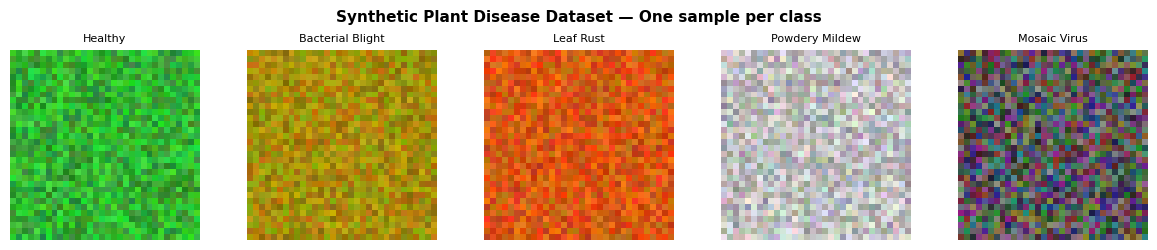

In [3]:
def make_plant_dataset(n_per_class=120, img_size=32, seed=42):
    # Creates structured synthetic "leaf images" where class determines
    # the dominant colour/texture pattern.
    rng = np.random.default_rng(seed)
    images, labels = [], []

    for cls in range(NUM_CLASSES):
        for _ in range(n_per_class):
            img = np.zeros((3, img_size, img_size), dtype=np.float32)

            if cls == 0:   # Healthy: green dominant
                img[1] = rng.uniform(0.5, 0.9, (img_size, img_size))  # green
                img[0] = rng.uniform(0.1, 0.3, (img_size, img_size))  # low red
                img[2] = rng.uniform(0.1, 0.3, (img_size, img_size))  # low blue

            elif cls == 1:   # Bacterial Blight: yellow-brown patches
                img[1] = rng.uniform(0.4, 0.7, (img_size, img_size))
                img[0] = rng.uniform(0.5, 0.8, (img_size, img_size))  # high red
                img[2] = rng.uniform(0.0, 0.1, (img_size, img_size))  # low blue

            elif cls == 2:   # Leaf Rust: orange-red spots
                img[1] = rng.uniform(0.2, 0.5, (img_size, img_size))
                img[0] = rng.uniform(0.7, 1.0, (img_size, img_size))  # very high red
                img[2] = rng.uniform(0.0, 0.15,(img_size, img_size))  # very low blue

            elif cls == 3:   # Powdery Mildew: whitish/grey (all high)
                base = rng.uniform(0.6, 0.9, (img_size, img_size))
                img[0] = base + rng.normal(0, 0.05, (img_size, img_size))
                img[1] = base + rng.normal(0, 0.05, (img_size, img_size))
                img[2] = base + rng.normal(0, 0.05, (img_size, img_size))

            else:            # Mosaic Virus: dark patches + high variance
                img[0] = rng.uniform(0.1, 0.6, (img_size, img_size))
                img[1] = rng.uniform(0.1, 0.6, (img_size, img_size))
                img[2] = rng.uniform(0.1, 0.6, (img_size, img_size))

            img = np.clip(img, 0, 1)
            images.append(img)
            labels.append(cls)

    images = torch.tensor(np.array(images), dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)
    return images, labels

X_all, y_all = make_plant_dataset(n_per_class=100)
n_total  = len(X_all)
n_train  = int(n_total * 0.8)
perm     = torch.randperm(n_total)
X_tr, y_tr = X_all[perm[:n_train]], y_all[perm[:n_train]]
X_vl, y_vl = X_all[perm[n_train:]], y_all[perm[n_train:]]

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=64)
print(f"Train: {len(X_tr)} samples | Val: {len(X_vl)} samples")

# Preview: show one sample per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(12, 2.5))
for cls in range(NUM_CLASSES):
    idx = (y_all == cls).nonzero(as_tuple=True)[0][0]
    img = X_all[idx].numpy().transpose(1, 2, 0)   # (H, W, 3)
    axes[cls].imshow(np.clip(img, 0, 1))
    axes[cls].set_title(CLASS_NAMES[cls], fontsize=8)
    axes[cls].axis('off')
plt.suptitle('Synthetic Plant Disease Dataset — One sample per class', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Build the Classifier — ResNet-18 with Fine-tuning

In [4]:
# ResNet-18: unfreeze last block (layer4) + replace FC head
classifier = models.resnet18(weights=None)

# Freeze all layers first
for param in classifier.parameters():
    param.requires_grad = False

# Unfreeze layer4 (last residual block) + new FC
for param in classifier.layer4.parameters():
    param.requires_grad = True

classifier.fc = nn.Linear(classifier.fc.in_features, NUM_CLASSES)
classifier    = classifier.to(device)

trainable_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in classifier.parameters())
print(f"Trainable: {trainable_params:,} / {total_params:,} total")
print(f"Architecture: stem → layer1 → layer2 → layer3 → [layer4 ✓] → [FC ✓]")

# Register Grad-CAM on the last conv output (layer4)
gradcam = GradCAM(classifier, classifier.layer4)
print("Grad-CAM registered on layer4")

Trainable: 8,396,293 / 11,179,077 total
Architecture: stem → layer1 → layer2 → layer3 → [layer4 ✓] → [FC ✓]
Grad-CAM registered on layer4


In [5]:
# Training loop
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, classifier.parameters()), lr=1e-3
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss()

train_losses, val_accs = [], []
t0 = time.time()

for epoch in range(12):
    classifier.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(classifier(xb), yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item()

    classifier.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            correct += (classifier(xb.to(device)).argmax(1) == yb.to(device)).sum().item()

    acc  = correct / len(X_vl) * 100
    loss_avg = total_loss / len(train_loader)
    train_losses.append(loss_avg)
    val_accs.append(acc)
    scheduler.step()

    if (epoch + 1) % 4 == 0:
        print(f"Epoch {epoch+1:2d}/12  loss={loss_avg:.4f}  val_acc={acc:.1f}%")

print(f"\nTraining complete in {time.time()-t0:.1f}s  |  Final val acc: {val_accs[-1]:.1f}%")

C:\Users\User\AppData\Local\Temp\ipykernel_17876\41917996.py:18: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward(); optimizer.step()


Epoch  4/12  loss=0.0012  val_acc=19.0%


Epoch  8/12  loss=0.0409  val_acc=80.0%


Epoch 12/12  loss=0.0003  val_acc=100.0%

Training complete in 11.8s  |  Final val acc: 100.0%


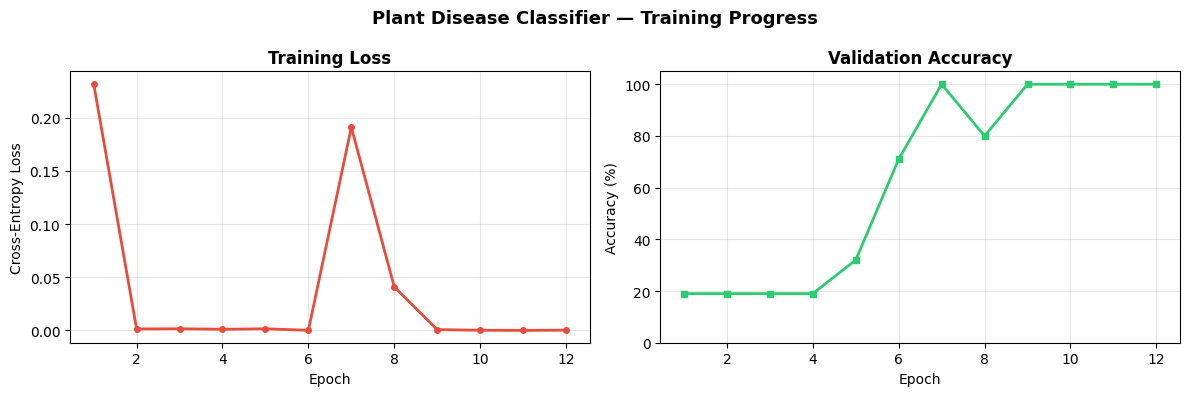

In [6]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 13), train_losses, '#e74c3c', linewidth=2, marker='o', ms=4)
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, 13), val_accs, '#2ecc71', linewidth=2, marker='s', ms=4)
axes[1].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

plt.suptitle('Plant Disease Classifier — Training Progress', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('plant_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Grad-CAM Visualisation

Now we apply Grad-CAM to see **which regions** the network focuses on for each class.

For each sample:
1. Forward pass → get logits
2. Backward pass for the target class → compute ∂y^c/∂A^k
3. Pool gradients → α^c_k weights
4. Weighted sum + ReLU → coarse heatmap
5. Upsample + overlay on image

C:\Users\User\AppData\Local\Temp\ipykernel_17876\561985373.py:34: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  output.backward(gradient=one_hot)
C:\Users\User\AppData\Local\Temp\ipykernel_17876\561985373.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap(colormap)(cam)[:, :, :3]  # (H, W, 3)


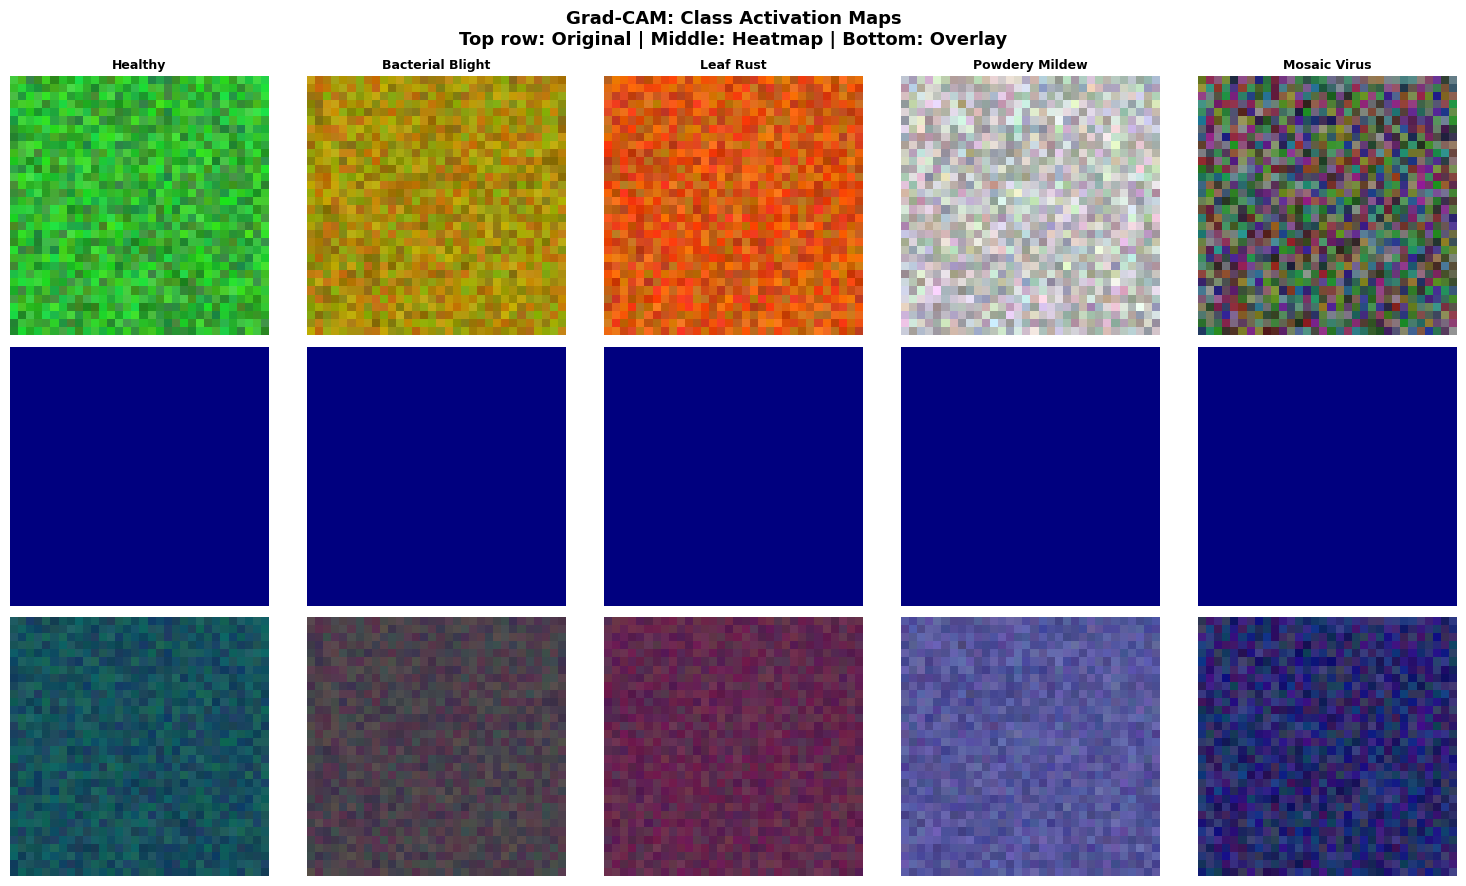

Saved: gradcam_visualization.png


In [7]:
# Apply Grad-CAM to one sample per class
classifier.eval()
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(15, 9))
fig.suptitle('Grad-CAM: Class Activation Maps\nTop row: Original | Middle: Heatmap | Bottom: Overlay',
             fontsize=13, fontweight='bold')

for cls in range(NUM_CLASSES):
    # Find a correctly predicted sample for this class
    candidates = (y_vl == cls).nonzero(as_tuple=True)[0]
    sample_img  = X_vl[candidates[0]].unsqueeze(0).to(device)
    sample_np   = X_vl[candidates[0]].numpy().transpose(1, 2, 0)  # (H, W, 3)

    # Grad-CAM
    cam, pred_cls = gradcam.generate(sample_img, target_class=cls)

    # Overlay
    overlay = overlay_heatmap(np.clip(sample_np, 0, 1), cam, alpha=0.55)

    # Row 0: original image
    axes[0, cls].imshow(np.clip(sample_np, 0, 1))
    axes[0, cls].set_title(CLASS_NAMES[cls], fontsize=9, fontweight='bold')
    axes[0, cls].axis('off')

    # Row 1: raw Grad-CAM heatmap
    axes[1, cls].imshow(cam, cmap='jet')
    axes[1, cls].axis('off')

    # Row 2: overlay
    axes[2, cls].imshow(overlay)
    axes[2, cls].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, rotation=90, labelpad=5)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=10, rotation=90, labelpad=5)
axes[2, 0].set_ylabel('Overlay', fontsize=10, rotation=90, labelpad=5)

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: gradcam_visualization.png")

## 5. Model Evaluation — Confusion Matrix & Per-class Accuracy

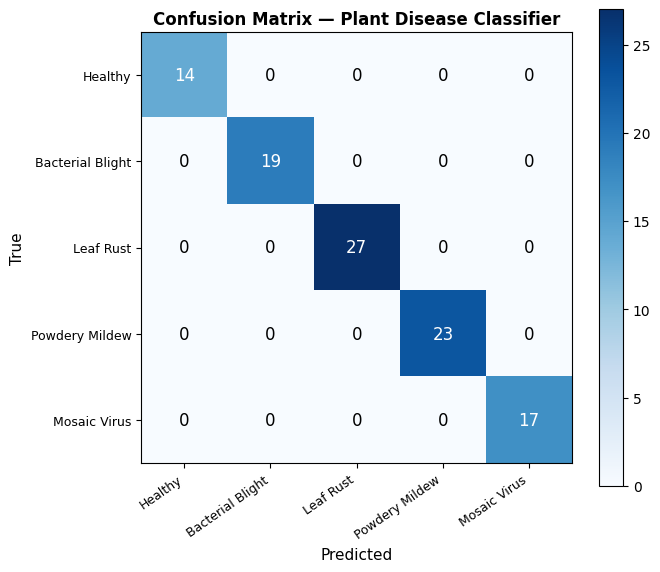


Per-class Accuracy:
-----------------------------------
  Healthy              100.0%  ████████████████████
  Bacterial Blight     100.0%  ████████████████████
  Leaf Rust            100.0%  ████████████████████
  Powdery Mildew       100.0%  ████████████████████
  Mosaic Virus         100.0%  ████████████████████

  Overall Accuracy:    100.0%


In [8]:
# Full evaluation on validation set
classifier.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        preds = classifier(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm_arr = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_arr, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix — Plant Disease Classifier', fontsize=12, fontweight='bold')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm_arr[i, j]), ha='center', va='center',
                fontsize=12, color='white' if cm_arr[i, j] > cm_arr.max()/2 else 'black')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\nPer-class Accuracy:")
print("-" * 35)
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    acc  = (all_preds[mask] == all_labels[mask]).mean() * 100
    bar  = '█' * int(acc / 5)
    print(f"  {name:<20} {acc:5.1f}%  {bar}")

overall = (all_preds == all_labels).mean() * 100
print(f"\n  Overall Accuracy:    {overall:.1f}%")

## 6. Grad-CAM on Wrong Predictions — Error Analysis

One of the most powerful uses of Grad-CAM is **error analysis**:
- When the model misclassifies, *where is it looking?*
- Is it confused by similar colour regions between two classes?
- Is it distracted by irrelevant areas?

In [9]:
# Find misclassified samples and visualise their Grad-CAM
wrong_idx = np.where(all_preds != all_labels)[0]

if len(wrong_idx) == 0:
    print("No misclassifications on validation set — perfect accuracy!")
else:
    n_show = min(4, len(wrong_idx))
    fig, axes = plt.subplots(3, n_show, figsize=(3.5 * n_show, 9))
    if n_show == 1:
        axes = axes[:, np.newaxis]
    fig.suptitle('Grad-CAM on Misclassified Samples\n(What the model "saw" when it was wrong)',
                 fontsize=12, fontweight='bold')

    for col, wi in enumerate(wrong_idx[:n_show]):
        true_cls = int(all_labels[wi])
        pred_cls = int(all_preds[wi])
        img_t    = X_vl[wi].unsqueeze(0).to(device)
        img_np   = X_vl[wi].numpy().transpose(1, 2, 0)

        # Grad-CAM for PREDICTED class (what the model was confident about)
        cam_pred, _ = gradcam.generate(img_t, target_class=pred_cls)
        overlay      = overlay_heatmap(np.clip(img_np, 0, 1), cam_pred, alpha=0.55)

        axes[0, col].imshow(np.clip(img_np, 0, 1)); axes[0, col].axis('off')
        axes[0, col].set_title(f"True: {CLASS_NAMES[true_cls]}\nPred: {CLASS_NAMES[pred_cls]}",
                               fontsize=8, color='red')
        axes[1, col].imshow(cam_pred, cmap='jet'); axes[1, col].axis('off')
        axes[2, col].imshow(overlay); axes[2, col].axis('off')

    axes[0, 0].set_ylabel('Image', fontsize=10)
    axes[1, 0].set_ylabel('Grad-CAM', fontsize=10)
    axes[2, 0].set_ylabel('Overlay', fontsize=10)
    plt.tight_layout()
    plt.savefig('gradcam_errors.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Saved: gradcam_errors.png  |  Showed {n_show} misclassified samples")

No misclassifications on validation set — perfect accuracy!


## 7. Key Takeaways

### Grad-CAM Summary
- **Grad-CAM = gradient × activation** — identify important feature maps by how much
  the loss responds to their activations
- **No architectural change** required — works on any CNN via hooks
- **Resolution is limited** by the spatial size of the last conv layer (7×7 for ResNet on 224×224)
- **Grad-CAM++** improves on this with better weighting (handles multi-instance cases)

### Transfer Learning + Explainability
- Training accuracy alone does not guarantee the model learned the *right* features
- Grad-CAM lets you **audit** whether the model looks at class-relevant regions
- In medical imaging / autonomous driving, this is not optional — it is a safety requirement
- If Grad-CAM shows the model highlighting the *background* (e.g., image watermarks),
  the dataset has a spurious correlation that must be fixed in data collection

### What We Built
```
✅ Structured 5-class synthetic plant dataset
✅ ResNet-18 fine-tuned (layer4 + FC unfrozen)
✅ Grad-CAM implemented from scratch with PyTorch hooks
✅ Class activation maps visualised per class
✅ Error analysis via Grad-CAM on misclassified samples
✅ Confusion matrix + per-class accuracy
```

---
**Week 10 Complete.** Next week (Week 11): Object Detection with Deep Learning —
Anchor boxes, IoU, NMS, R-CNN family, YOLO architecture.
